# Mental_Health_and_Social_Media_Balance_Dataset Using Analysis
## Social Media and Mental Health Balance

A data analytics project which explores correlations between daily screen hours, stress, and sleep quality.

## Installation python libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn missingno


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Necassary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Reading Data from Dataset  (First 5 data)

In [3]:
url = "https://raw.githubusercontent.com/coderboe/Open-data-Analysis/main/Mental_Health_and_Social_Media_Balance_Dataset.csv"

df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


## Reading for Last 5 data

In [4]:
df.tail()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
495,U496,23,Male,6.9,5.0,7.0,4.0,2.0,X (Twitter),10.0
496,U497,43,Female,5.6,7.0,6.0,5.0,2.0,Facebook,9.0
497,U498,41,Male,7.7,5.0,7.0,2.0,2.0,LinkedIn,8.0
498,U499,23,Male,4.2,9.0,7.0,0.0,2.0,Facebook,9.0
499,U500,43,Female,5.9,5.0,8.0,3.0,3.0,X (Twitter),7.0


## Basic information

In [5]:
print("Shape:", df.shape)
df.info()
df.describe().T

Shape: (500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


,count,mean,std,min,25%,50%,75%,max
Age,500.0,32.988,9.960637,16.0,24.0,34.0,41.0,49.0
Daily_Screen_Time(hrs),500.0,5.530,1.734877,1.0,4.3,5.6,6.7,10.8
Sleep_Quality(1-10),500.0,6.304,1.529792,2.0,5.0,6.0,7.0,10.0
Stress_Level(1-10),500.0,6.618,1.542996,2.0,6.0,7.0,8.0,10.0
Days_Without_Social_Media,500.0,3.134,1.858751,0.0,2.0,3.0,5.0,9.0
Exercise_Frequency(week),500.0,2.448,1.428067,0.0,1.0,2.0,3.0,7.0
Happiness_Index(1-10),500.0,8.376,1.524228,4.0,7.0,9.0,10.0,10.0


## Check missing values

In [6]:
df.isna().sum()

User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64

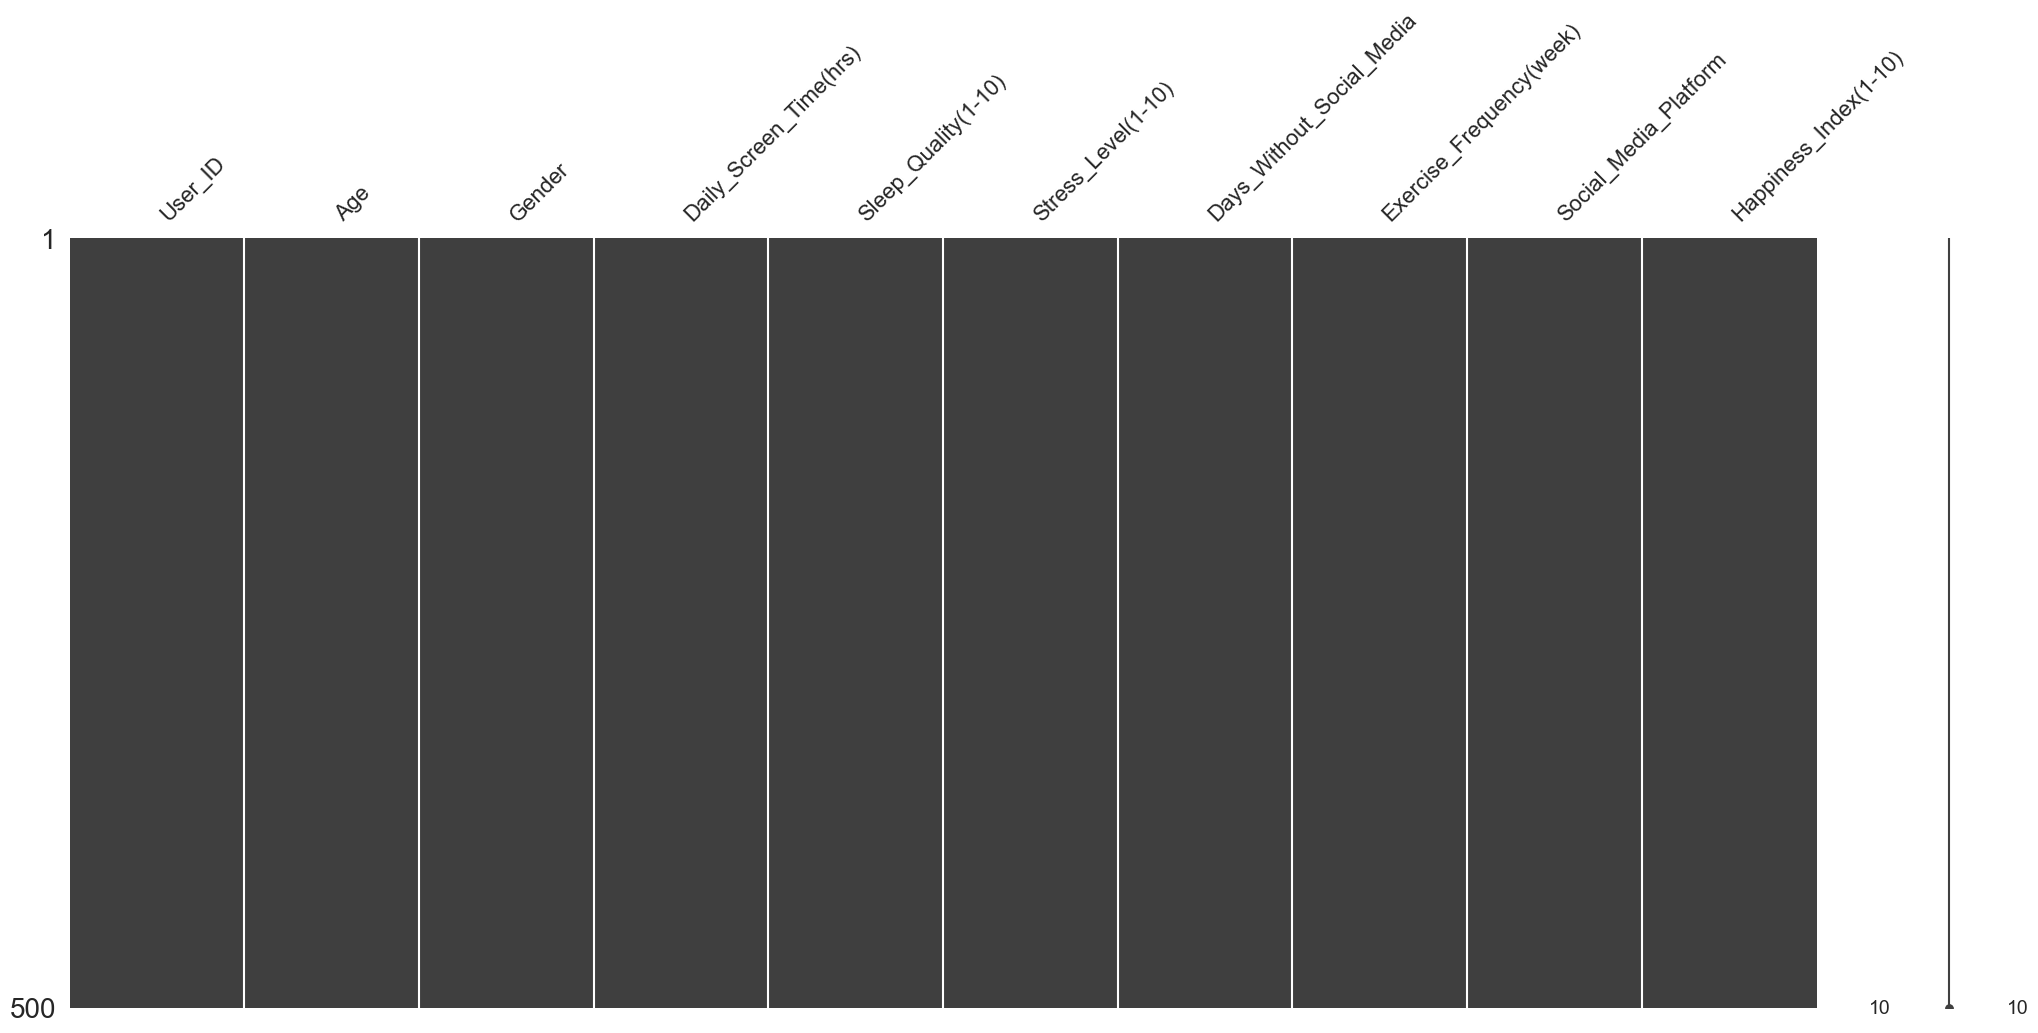

In [7]:
msno.matrix(df)
plt.show()

## Data cleaning

In [8]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].astype(str).str.strip()

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [10]:
cat_cols = df.select_dtypes(exclude=np.number).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

## Exploratory Data Analysis (EDA)

## Using Histograms

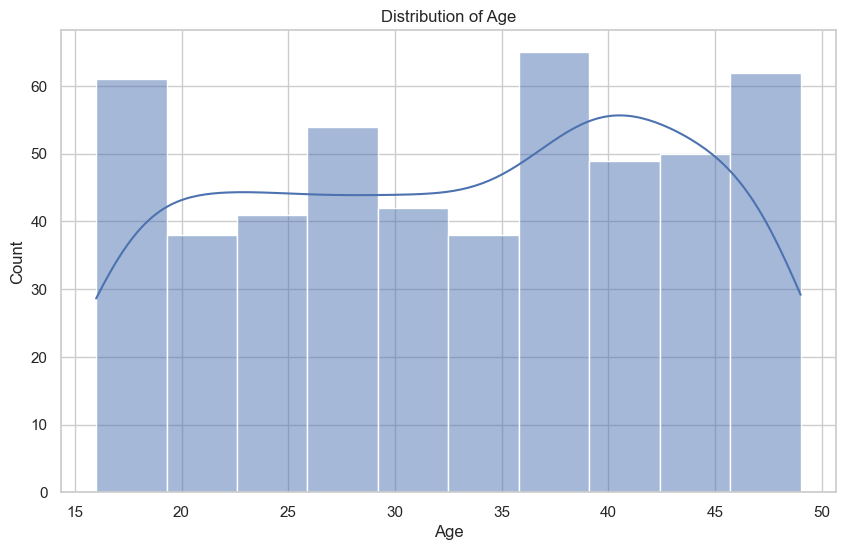

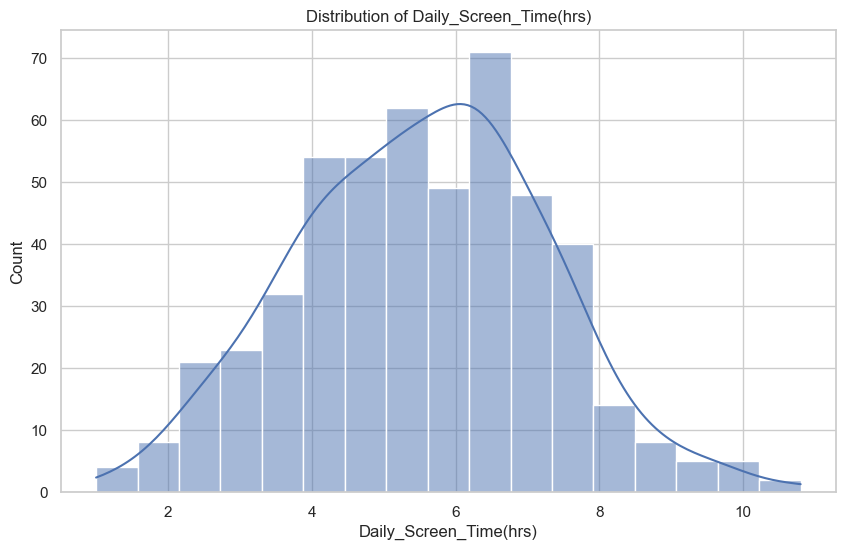

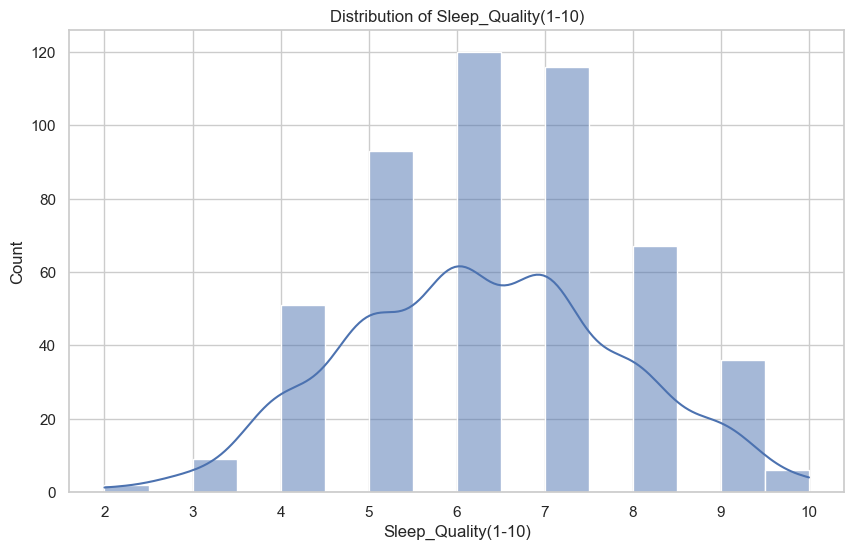

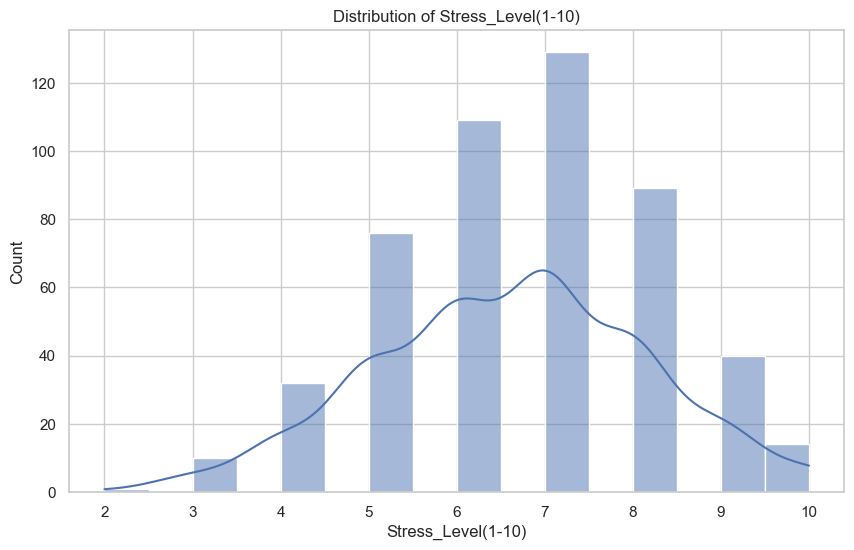

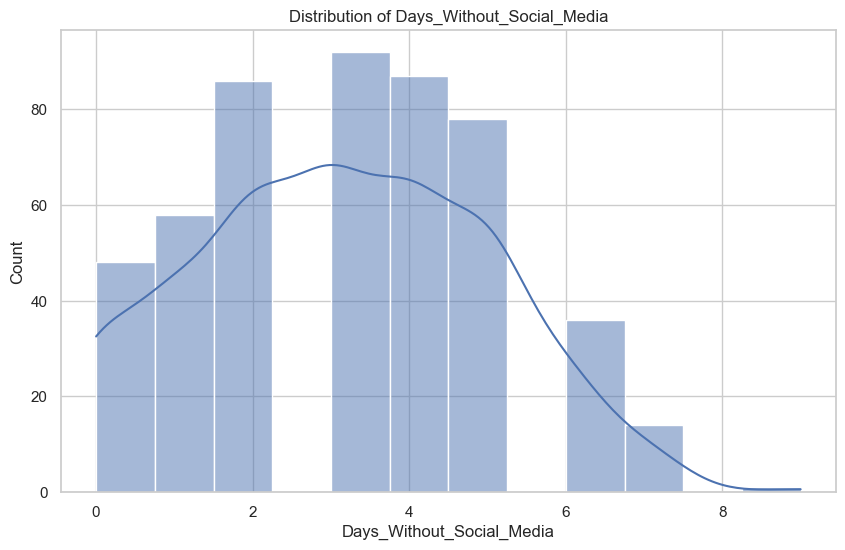

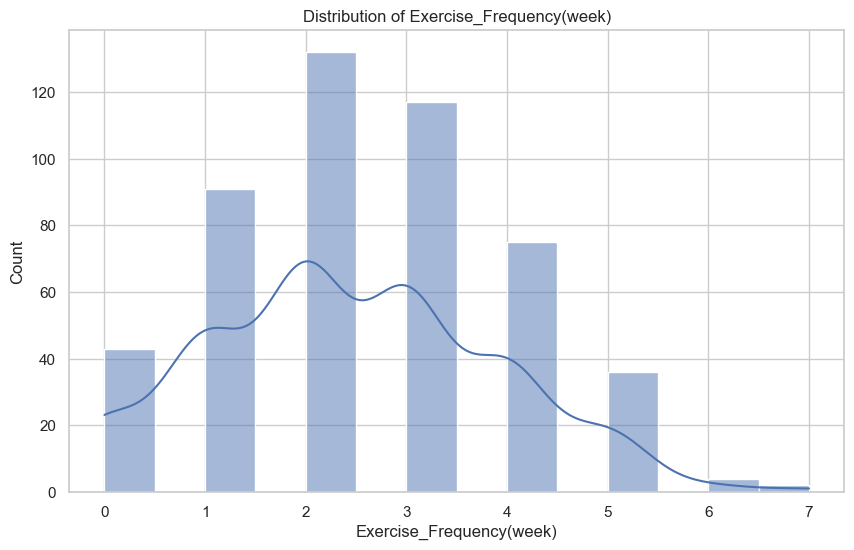

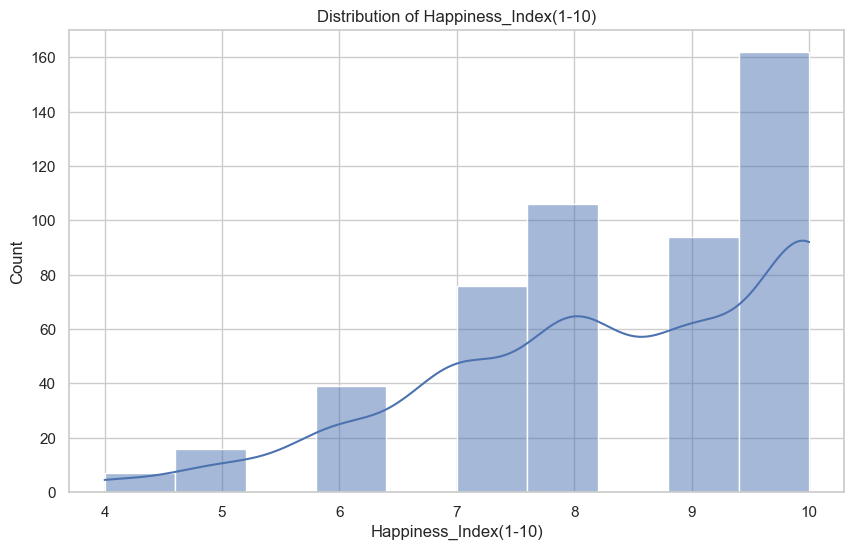

In [11]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Using Boxplots

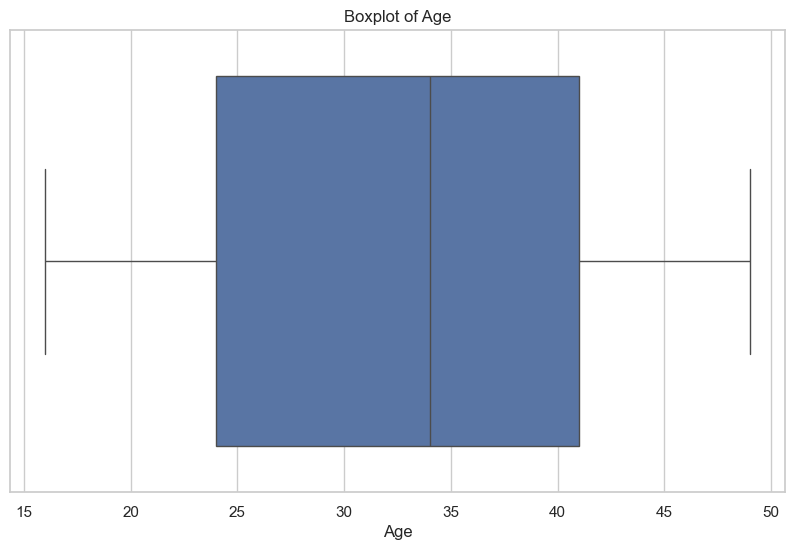

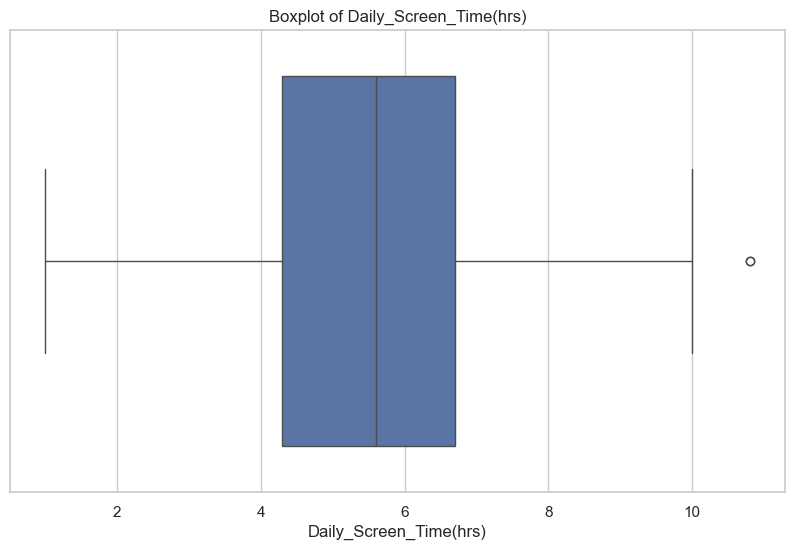

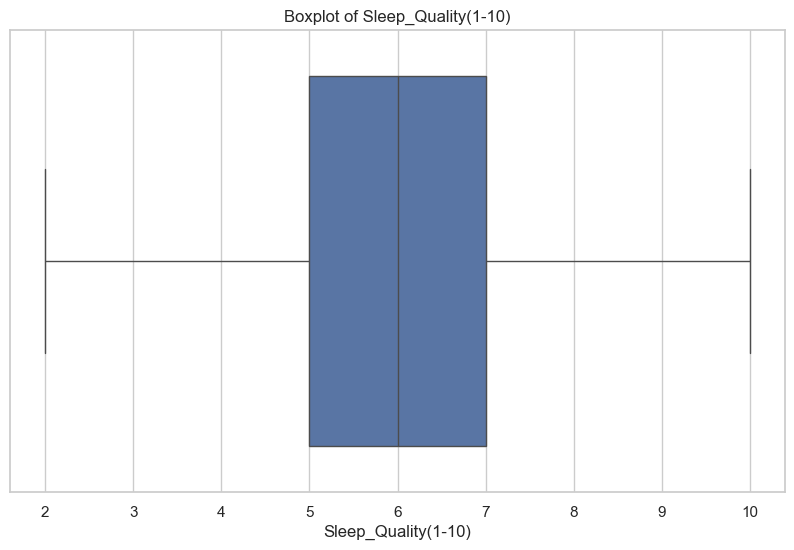

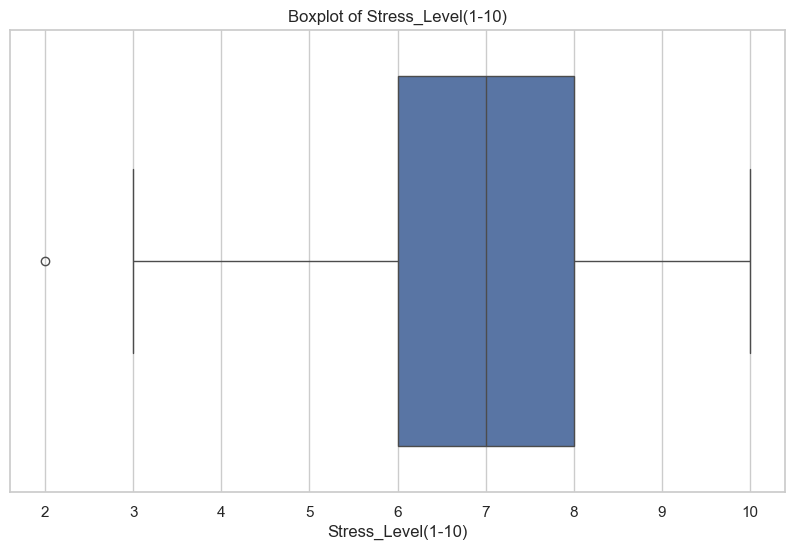

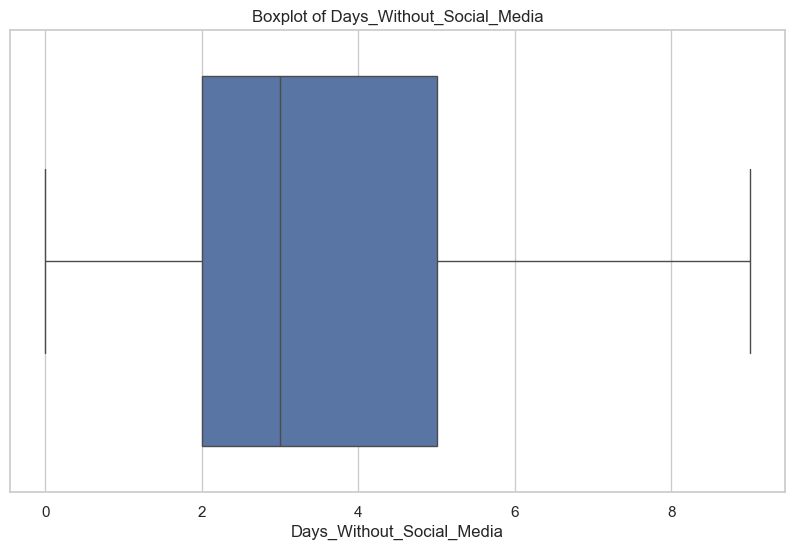

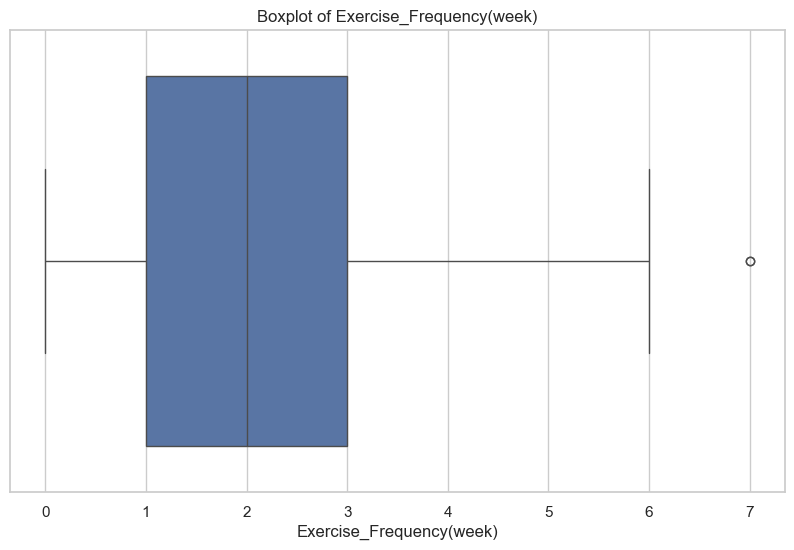

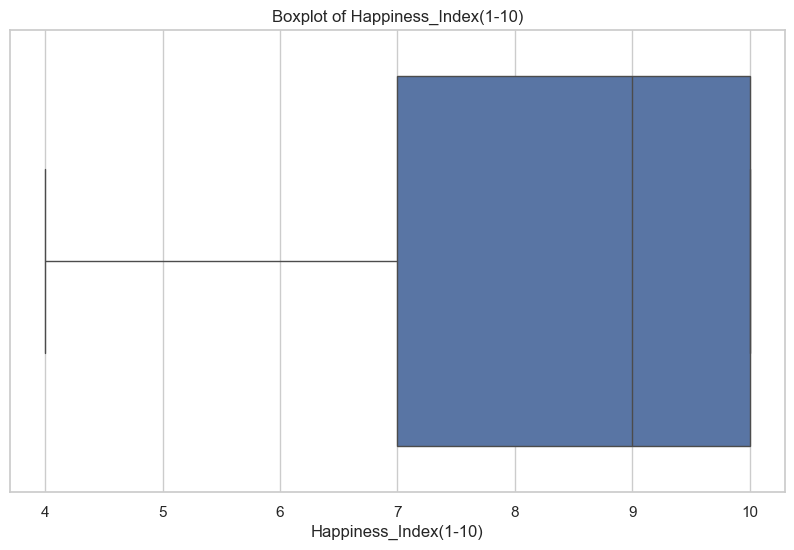

In [12]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Using Correlation heatmap

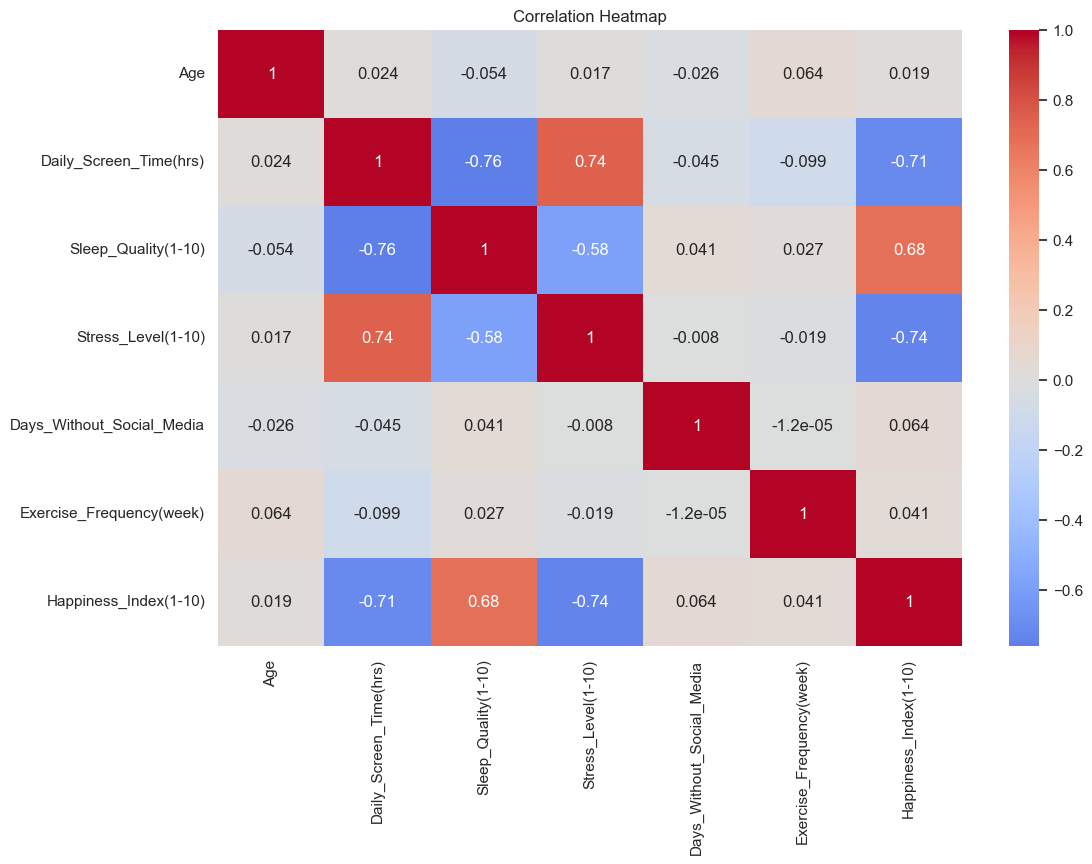

In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()